# Simulation

PyGOM calls upon numerical solvers contained in the `simulation` module which allow the user to evaluate both the **deterministic** and **stochastic** time evolution of their model using methods {func}`solve_deterministic` and {func}`solve_stochastic` respectively.
These methods work with both fixed and random parameters as introduced in the {doc}`previous section <../notebooks/model_params>`.

## Preliminary set-up

We begin our demonstration by defining an SIR model in PyGOM.

In [8]:
from pygom import SimulateOde, Transition, TransitionType
import matplotlib.pyplot as plt
import numpy as np
import random

#####################
# Model specification
#####################
stateList = ['S', 'I', 'R']
paramList = ['beta', 'gamma', 'N']
transitionList = [
    Transition(origin='S', destination='I', equation='beta*S*I/N', transition_type=TransitionType.T),
    Transition(origin='I', destination='R', equation='gamma*I', transition_type=TransitionType.T)
    ]

############
# Parameters
############
n_pop = 1e4      # Total population is fixed
beta_mn = 0.35   # Infectivity, beta. Gives the actual value for fixed params and mean for random distribution.
gamma_mn = 0.25  # Recovery rate, gamma.

# Fixed
fixed_param_set=[('beta', beta_mn), ('gamma', gamma_mn), ('N', n_pop)]

# Random
gamma_var = (gamma_mn / 10)**2  # Set the standard deviation to be 1/10th of the mean value
gamma_shape = (gamma_mn**2) / gamma_var
gamma_rate = gamma_mn / gamma_var

beta_var = (beta_mn / 10)**2  # Set the standard deviation to be 1/10th of the mean value
beta_shape = (beta_mn**2) / beta_var
beta_rate = beta_mn / beta_var

from pygom.utilR import rgamma
random_param_set = dict()  # container for random param set
random_param_set['gamma'] = (rgamma, {'shape': gamma_shape, 'rate': gamma_rate})
random_param_set['beta'] = (rgamma, {'shape': beta_shape, 'rate': beta_rate})
random_param_set['N'] = n_pop

TODO: seeds

It is compulsory to supply initial conditions as well as  desired time points for the output.
Depending on the method, we may specify the latter as either as an array of desired timepoints or as a simulation end time.

Note that t_eval is not integrator but output.

In [9]:
# Initial conditions
i0 = 10
x0 = [n_pop-i0, i0, 0]

# Time range and increments
t0 = 0.0                              # initial time
tmax = 200.0                          # maximum time over which to run solver
dt = 5.0                              # timestep
t_eval = np.arange(t0, tmax, dt)      # times at which solution output will be evaluated

## Deterministic evolution

Deterministic time evolution of the system is handled by the pygom function `solve_deterministic`.
This takes the ODE representation of the model and then integrates using {func}`scipy.integrate.solve_ivp`.
Prior to solving, pygom will augment the set of ODEs with equations for variables which track the numbers of times each transition occurs, thus freeing the user from doing so themselves or needing to reverse engineer these quantities from the output.
Such a feature is obviously useful to anyone who, for example, has required the incidence (new infections in a given time interval) rather than the prevalence (number of infected indivuduals at a given time) which the I in SIR encodes for.
Whilst the underlying `scipy` solver is obscured by this wrapping, any parameters which might be passed to {func}`scipy.integrate.solve_ivp` can be included as key word arguments in {func}`solve_deterministic`, so no functionality of the integrator is lost.

We begin with the simple case of fixed parameters by initialising a {class}`SimulateOde` object with our fixed parameters, `fixed_param_set`:

In [3]:
# Set up pygom object (D_F suffix implies Deterministic_Fixed)
model_D_F = SimulateOde(stateList, paramList, transition=transitionList)
model_D_F.initial_values = (x0, t_eval[0])  # (initial state conditions, initial timepoint)
model_D_F.parameters = fixed_param_set

The solution is then found via `solve_deterministic`, specifying the required time steps.

In [4]:
solution_D_F = model_D_F.solve_deterministic(t_eval)

We now inspect the model output class.
In addition to the simulation result, the output data class contains meta data on the solver configuration and optional details on solver performance.

For deterministic and, as we'll see shortly, stochastic tau leap methods, the solution attribute `result` contains the timepoints, `t`, the state values at those timepoints, `x`, and the number of times each transition occurs between each timepoint, `jumps`.
In this example, the dimensions of these components of the simulation results are such that (i) the state array has 3 columns for states S, I and R and a row for each timepoint (ii) the transition array has 2 columns for the infection and recovery transitions and has 1 fewer row than the time array because these quantities are defined between consecutive timepoints.

In [ ]:
t = solution_D_F.result.t
y = solution_D_F.result.x
jump = solution_D_F.result.jumps

print(f'Timepoints shape: {t.shape}')
print(f'State shape: {y.shape}')
print(f'Transitions shape: {jump.shape}')

Timepoints array shape: (40,)
State array shape: (40, 3)
Transition array shape: (39, 2)


We may plot the states through time as follows:

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_23868\2381169133.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


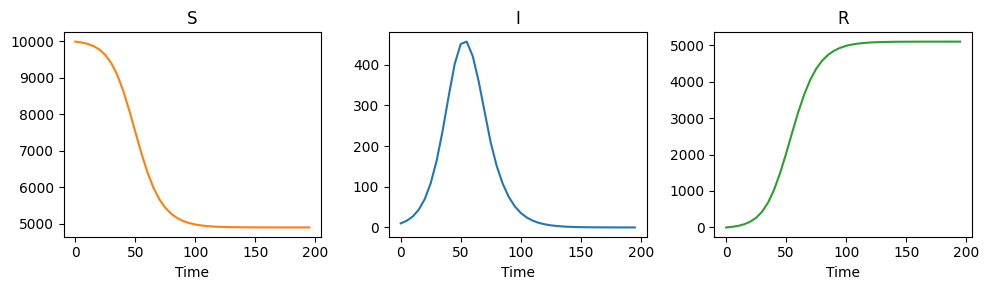

In [6]:
fig, ax = plt.subplots(1, 3, layout='constrained', figsize=(10, 3))

colours=["C1", "C0", "C2"]

for i in range(3):
    ax[i].plot(t, y[:,i], color=colours[i])
    ax[i].set_xlabel('Time')
    ax[i].set_title(stateList[i])
# plt.suptitle("Deterministic simulation with fixed parameters")
plt.tight_layout()
plt.show()

We can also produce plots for the transitions.
In this case, a bar plot might be more appropriate to illustrate that we are showing occurances per interval.

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_23868\731768211.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


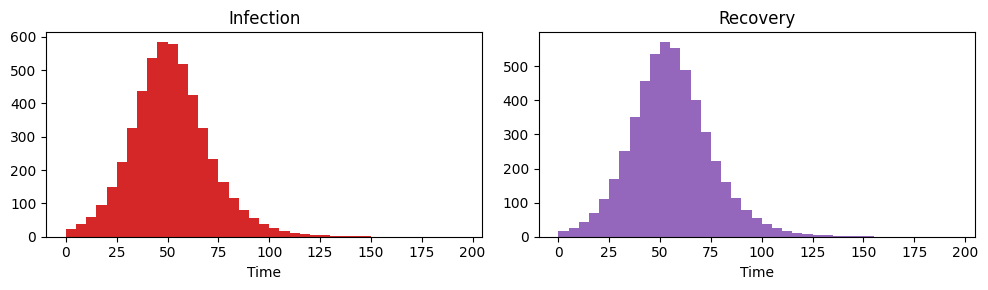

In [10]:
fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(10, 3))

colours = ["C3", "C4"]
transition_names = ["Infection", "Recovery"]

# Compute widths
widths = np.diff(t)
t_min = t[:-1]

for i in range(2):
    ax[i].bar(t_min, jump[:,i], width=widths, color=colours[i], align='edge')
    ax[i].set_xlabel('Time')
    ax[i].set_title(f"{transition_names[i]}")
plt.tight_layout()
plt.show()

We can just specify tmax and scipy detemrined timepoints are yielded.

The underlying solution should be the same, just the points at which it is evaluated.

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_23868\1181506244.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


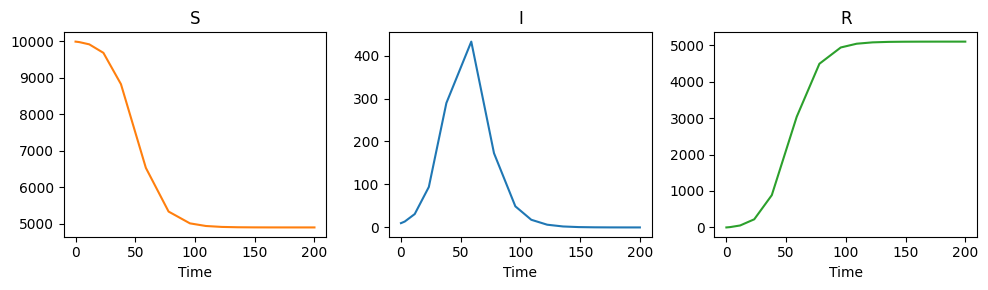

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_23868\1181506244.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


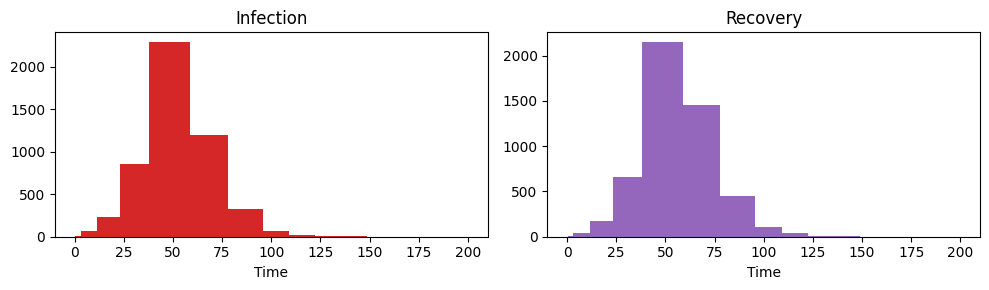

In [11]:
solution_D_F = model_D_F.solve_deterministic(tmax)
t = solution_D_F.result.t
y = solution_D_F.result.x
jump = solution_D_F.result.jumps

fig, ax = plt.subplots(1, 3, layout='constrained', figsize=(10, 3))

colours=["C1", "C0", "C2"]

for i in range(3):
    ax[i].plot(t, y[:,i], color=colours[i])
    ax[i].set_xlabel('Time')
    ax[i].set_title(stateList[i])
# plt.suptitle("Deterministic simulation with fixed parameters")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(10, 3))

colours = ["C3", "C4"]
transition_names = ["Infection", "Recovery"]

# Compute widths
widths = np.diff(t)
t_min = t[:-1]

for i in range(2):
    ax[i].bar(t_min, jump[:,i], width=widths, color=colours[i], align='edge')
    ax[i].set_xlabel('Time')
    ax[i].set_title(f"{transition_names[i]}")
plt.tight_layout()
plt.show()

## Stochastic evolution

The approximation that numbers of individuals in each state may be treated as a continuum break down when their sizes are small.
In this regime, transitions between states do not represent continuous flows but are instead stochastic events that occur at rates governed by the current state of the system.

A CTMC assumption that waiting times for these events to occur are exponentially distributed (memoryless), allows for quicker evaluation of the dynamics.

PyGOM has 4 methods to deal with this that fall into 2 broader categories of exact and tau leap.

Exact implies every reaction is accounted for. We have direct and first reaction though one is much faster.

Tau leap comes in fixed or adaptive. The main objective of adaptive is to free user from input. Until these are better....

<!-- Two common algorithms have been implemented for use during simulation; the reaction method {cite}`Gillespie1977` and the $\tau$-Leap method
{cite}`Cao2006`.
The two change interactively depending on the size of the states. -->

### Tau leap

As previously, we define a model and pass our fixed parameters `fixed_param_set`.
However, this time we employ the function `solve_stochastic` to allow for stochastic time evolution:

TODO: Method must be specified!

TODO: can get t0 from t array if supplied

In [43]:
# Set up pygom object
model = SimulateOde(stateList, paramList, transition=transitionList)
model.initial_values = (x0, t_eval[0])

n_sim = 100  # number of simulations
model.parameters = fixed_param_set

result = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    iteration=n_sim,
    seed=0)

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\post_processing.py:121: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  density = np.divide(jumps[:, i], dt, where=dt>0)


C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_15844\2644375644.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


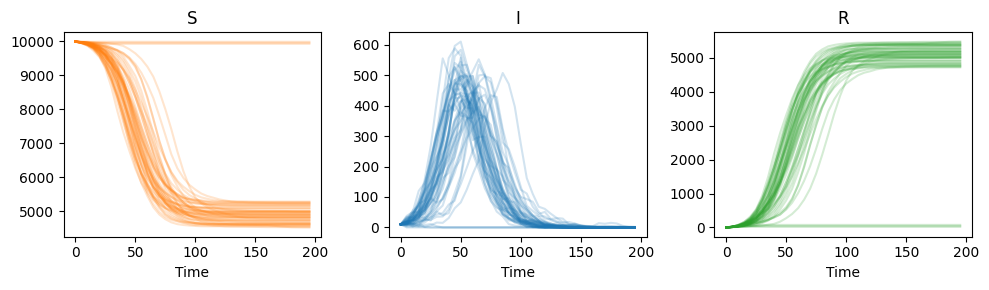

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_15844\2644375644.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


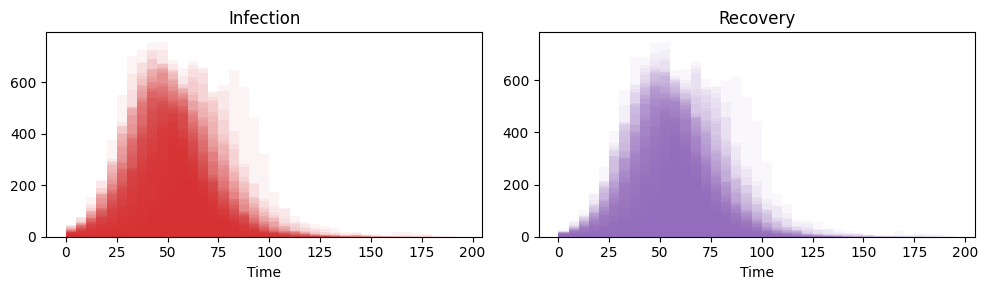

In [51]:
# Delete failed epidemics
t = result[0].result.t

fig, ax = plt.subplots(1, 3, layout='constrained', figsize=(10, 3))
colours=["C1", "C0", "C2"]

#########################
# Individual trajectories
#########################

# Select 50 simulations to plot
i_subset = np.arange(0, 50)

for state_idx in range(3):
    for sim_idx in i_subset:
        ax[state_idx].plot(t, result[sim_idx].result.x[:, state_idx], color=colours[state_idx], alpha=0.2)
    ax[state_idx].set_title(stateList[state_idx])
    ax[state_idx].set_xlabel('Time')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(10, 3))
colours = ["C3", "C4"]
transition_names = ["Infection", "Recovery"]

# Compute widths
widths = np.diff(t)
t_min = t[:-1]

for jump_idx in range(2):
    for sim_idx in range(50):
        ax[jump_idx].bar(t_min, result[sim_idx].result.jumps[:, jump_idx], width=widths, color=colours[jump_idx], align='edge', alpha=0.05)
        ax[jump_idx].set_xlabel('Time')
        ax[jump_idx].set_title(transition_names[jump_idx])
plt.tight_layout()
plt.show()

### Exact

As previously, we define a model and pass our fixed parameters `fixed_param_set`.
However, this time we employ the function `solve_stochast` to allow for stochastic time evolution:

TODO: Method must be specified!

TODO: can get t0 from t array if supplied

In [52]:
result = model.solve_stochastic(
    t=tmax,
    method="direct",
    iteration=10,
    seed=0)

Now output is of EventOutput type

In [53]:
print(result[0].result.t.shape)
print(result[0].result.x.shape)
print(result[0].result.event_id.shape)

(9417,)
(9417, 3)
(9416,)


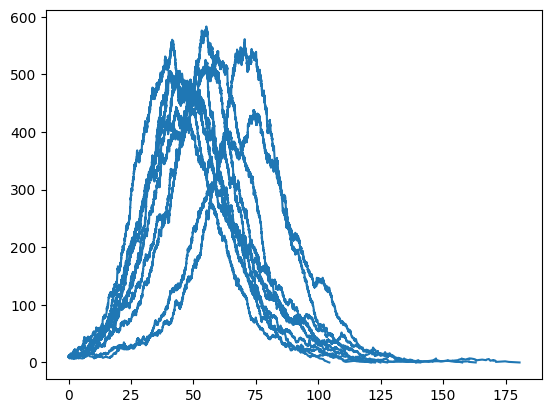

In [54]:
for i in range(10):
    plt.plot(result[i].result.t, result[i].result.x[:, 1], color="C0")
plt.show()

Can always use exact but then bin output if we specify bins:

You could always post process. Maybe if simualtion was time consuming you don't want to rerun just to change the bins.

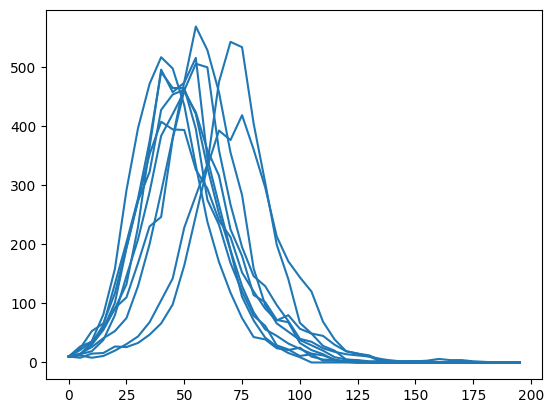

In [56]:
result = model.solve_stochastic(
    t=t_eval,
    method="direct",
    iteration=10,
    seed=0)

for i in range(10):
    plt.plot(result[i].result.t, result[i].result.x[:, 1], color="C0")
plt.show()

### Summary

In most cases it is up to the user to decide on the most appropriate method.

This will most likely be tau leap.

Until adaptive is developed, we recommend fixed tau. Timestep sufficiently small ma non troppo.

Before we inspect the epidemic time series, we plot the distribution of final epidemic sizes.

Note: benchmarking of the solvers ensures:
1) failure probability
2) successful mean size
3) successful standard deviation

Output is now a list for each iter

In [23]:
y = np.array([z.result.x for z in result])
jump = np.array([z.result.jumps for z in result])

print(y.shape)
print(jump.shape)

(100, 40, 3)
(100, 39, 2)


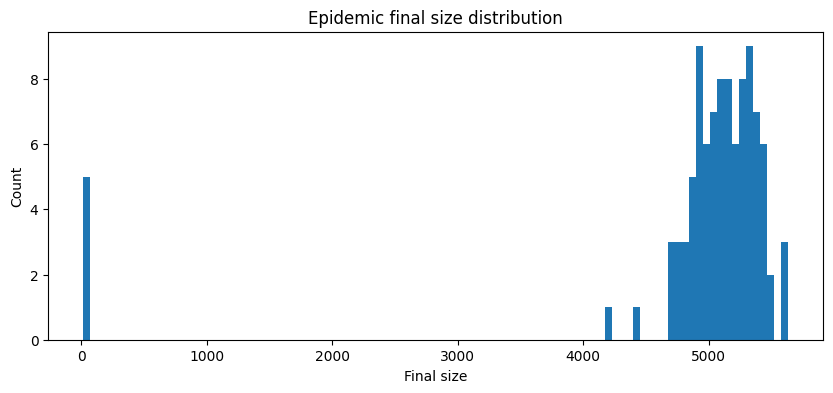

In [86]:
final_size = y[:, -1, 2]

plt.figure(figsize=(10, 4))
plt.title("Epidemic final size distribution")
plt.xlabel("Final size")
plt.ylabel("Count")
plt.hist(final_size, bins=100, color="C0")
plt.show()

We see that 28 of the 1000 simulations (2.8%) have final sizes very close to zero.
In these cases, the chain of infections reaches stochastic extinction before an epidemic is able to take off, as can be seen when plotting a selection of these failed epidemics.

TODO: change number

TODO: note that non integer values are possible for some methods

(0.0, 60.0)

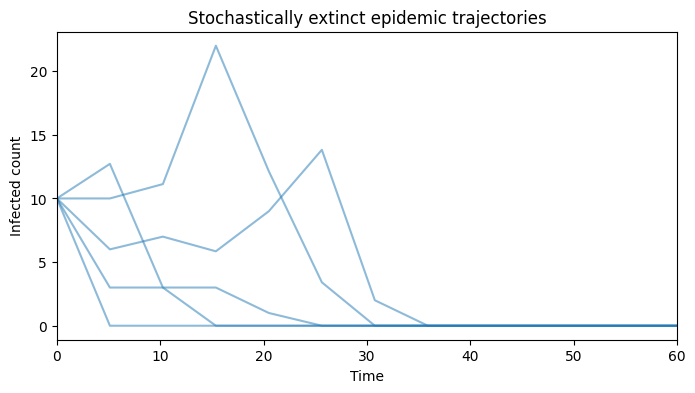

In [26]:
# Plot failed epidemics
i_failure = np.where(final_size <= 1000)[0]
y_fail = y[i_failure]

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(len(i_failure)):
    ax.plot(t, y_fail[i, :, 1], color="C0", alpha=0.5)
ax.set_title("Stochastically extinct epidemic trajectories")
ax.set_xlabel("Time")
ax.set_ylabel("Infected count")
ax.set_xlim(0, 60)

We proceed to eliminate these when plotting our simulation outputs, since we'd like to compare the output here with our deterministic results (which, by design, do not exhibit stochastic extinction):

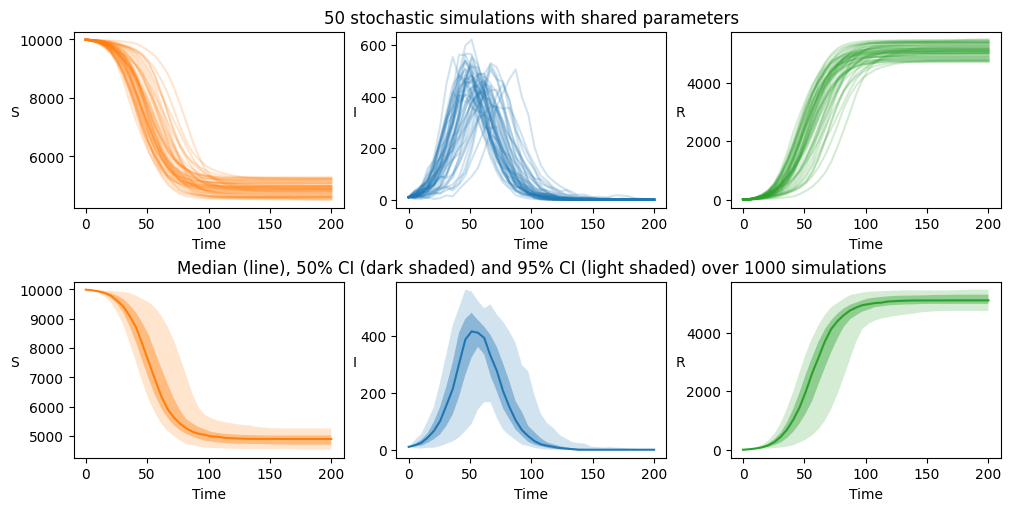

In [ ]:
# Delete failed epidemics
y = np.array([z.result.x for z in result])
jump = np.array([z.result.jumps for z in result])

i_success = np.where(final_size >= 1000)[0]
y_success = y[i_success]

fig, ax = plt.subplots(2, 3, layout='constrained', figsize=(10, 6))
colours=["C1", "C0", "C2"]

#########################
# Individual trajectories
#########################

# Select 50 simulations to plot
i_subset = np.arange(0, 50)

for state_idx in range(3):
    for sim_idx in i_subset:
        ax[0][state_idx].plot(t, y_success[sim_idx, :, state_idx], color=colours[state_idx], alpha=0.2)
    ax[0][state_idx].set_ylabel(stateList[state_idx], rotation=0)
    ax[0][state_idx].set_xlabel('Time')

######################
# Confidence intervals
######################

p = np.percentile(y_success, [2.5, 25, 50, 75, 97.5], axis=0)
lolo, lo, md, hi, hihi = p

for state_idx in range(3):
    # Plot CI's
    ax[1][state_idx].fill_between(t, lolo[:, state_idx], hihi[:, state_idx], alpha=0.2, facecolor=colours[state_idx])
    ax[1][state_idx].fill_between(t, lo[:, state_idx], hi[:, state_idx], alpha=0.4, facecolor=colours[state_idx])
    ax[1][state_idx].plot(t, md[:, state_idx], color=colours[state_idx])
    ax[1][state_idx].set_ylabel(stateList[state_idx], rotation=0)
    ax[1][state_idx].set_xlabel('Time')

# Titles
ax[0][1].set_title("50 stochastic simulations with shared parameters")
ax[1][1].set_title("Median (line), 50% CI (dark shaded) and 95% CI (light shaded) over 1000 simulations")

plt.show()

Also jumps

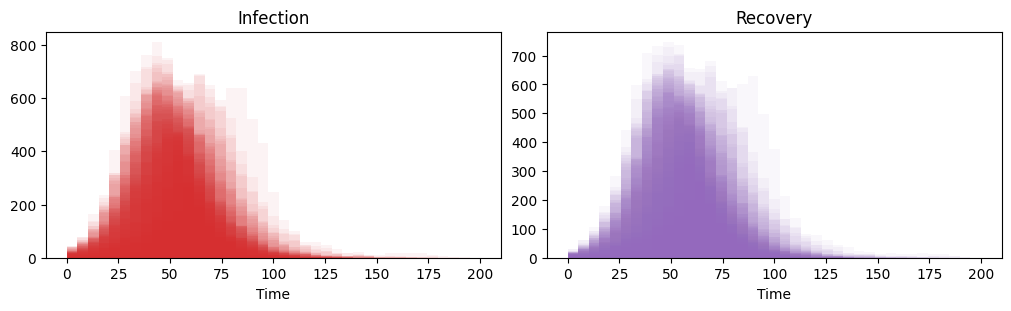

In [ ]:
# Delete failed epidemics
jump_success = jump[i_success]

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(10, 3))
colours = ["C3", "C4"]
transition_names = ["Infection", "Recovery"]

# Compute widths
widths = np.diff(t)
t_min = t[:-1]


# j = 0

for j in range(50):
    for i in range(2):
        ax[i].bar(t_min, jump_success[j, :, i], width=widths, color=colours[i], align='edge', alpha=0.05)
        # axarr[i].step(t_min, jump_success[j, :, i], color="black", alpha=0.5, where="post")
        ax[i].set_xlabel('Time')
        ax[i].set_title(transition_names[i])

plt.show()

In [76]:
result = model.solve_stochastic(
    t=t,
    method="direct",
    iteration=100,
    seed=0)

(9417,)
(9417, 3)
(9416,)


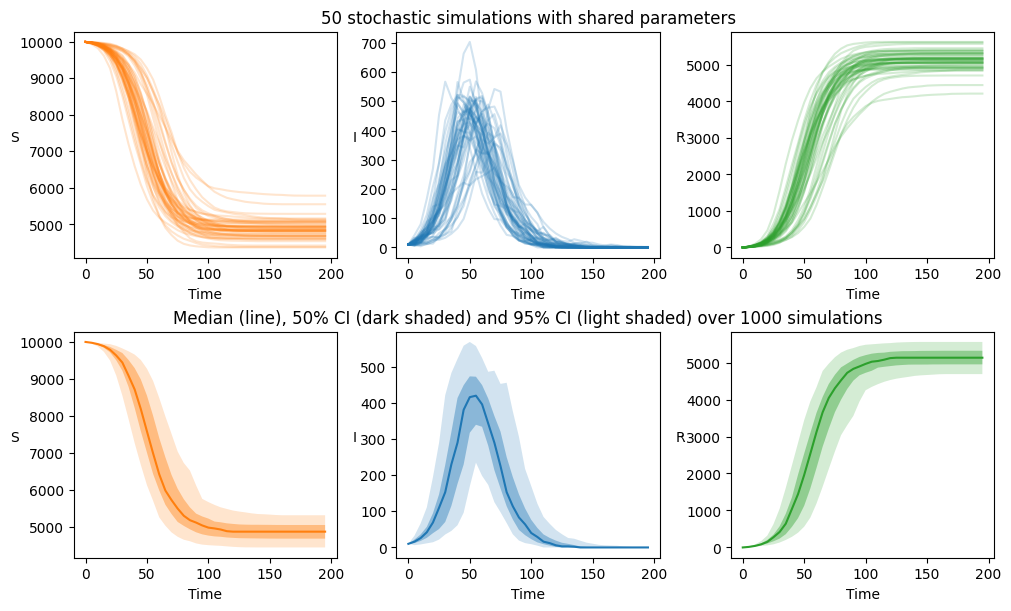

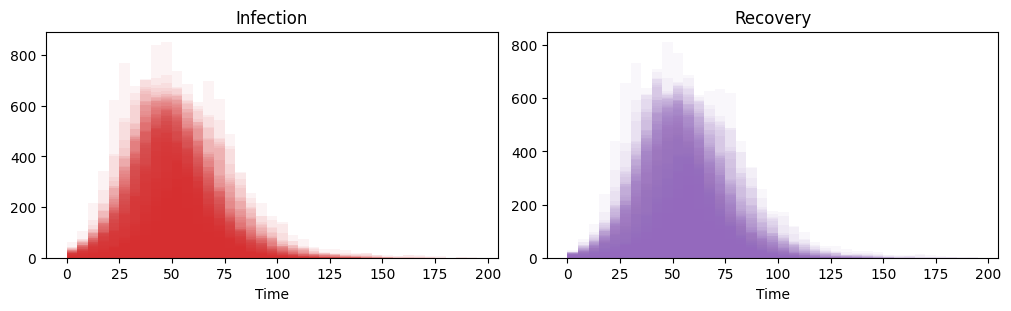

In [79]:
# Delete failed epidemics
y = np.array([z.result.x for z in result])
jump = np.array([z.result.jumps for z in result])
final_size = y[:, -1, 2]
i_success = np.where(final_size >= 1000)[0]
y_success = y[i_success]

fig, ax = plt.subplots(2, 3, layout='constrained', figsize=(10, 6))
colours=["C1", "C0", "C2"]

#########################
# Individual trajectories
#########################

# Select 50 simulations to plot
i_subset = np.arange(0, 50)

for state_idx in range(3):
    for sim_idx in i_subset:
        ax[0][state_idx].plot(t, y_success[sim_idx, :, state_idx], color=colours[state_idx], alpha=0.2)
    ax[0][state_idx].set_ylabel(stateList[state_idx], rotation=0)
    ax[0][state_idx].set_xlabel('Time')

######################
# Confidence intervals
######################

p = np.percentile(y_success, [2.5, 25, 50, 75, 97.5], axis=0)
lolo, lo, md, hi, hihi = p

for state_idx in range(3):
    # Plot CI's
    ax[1][state_idx].fill_between(t, lolo[:, state_idx], hihi[:, state_idx], alpha=0.2, facecolor=colours[state_idx])
    ax[1][state_idx].fill_between(t, lo[:, state_idx], hi[:, state_idx], alpha=0.4, facecolor=colours[state_idx])
    ax[1][state_idx].plot(t, md[:, state_idx], color=colours[state_idx])
    ax[1][state_idx].set_ylabel(stateList[state_idx], rotation=0)
    ax[1][state_idx].set_xlabel('Time')

# Titles
ax[0][1].set_title("50 stochastic simulations with shared parameters")
ax[1][1].set_title("Median (line), 50% CI (dark shaded) and 95% CI (light shaded) over 1000 simulations")

plt.show()

# Delete failed epidemics
jump_success = jump[i_success]

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(10, 3))
colours = ["C3", "C4"]
transition_names = ["Infection", "Recovery"]

# Compute widths
widths = np.diff(t)
t_min = t[:-1]

for j in range(50):
    for i in range(2):
        ax[i].bar(t_min, jump_success[j, :, i], width=widths, color=colours[i], align='edge', alpha=0.05)
        # axarr[i].step(t_min, jump_success[j, :, i], color="black", alpha=0.5, where="post")
        ax[i].set_xlabel('Time')
        ax[i].set_title(transition_names[i])

plt.show()

### Random parameters

Finally, we explore a scenario where we wish to solve for a stochastic system with parameters drawn randomly from some distributions.
Using the random parameter set, `random_param_set`, defined previously

In [ ]:
# Set up pygom object
model = SimulateOde(stateList, paramList, transition=transitionList)
model.initial_values = (x0, t[0])

# In this case n_sim and n_param_draw mean the same thing since we have new parameter set per simulation
model.parameters = random_param_set
solution_S_R, simJump, simT = model.solve_stochastic(t, n_sim, full_output=True)

Again, we begin our analysis by inspecting the final size distribution.

In [ ]:
y_S_R=np.dstack(solution_S_R)

final_size_S_R=y_S_R[-1, 2, :]
plt.figure(figsize=(8, 4))
plt.title("Epidemic final size distribution")
plt.xlabel("Final size")
plt.ylabel("Count")
plt.hist(final_size_S_R, bins=100)
plt.show()

We see that the final size distribution is much more spread out, owing to increased variation in the parameters.
The threshold value separating failed and successful epidemics is less clear cut in this case and we judge this by eye to be 2000.
Again, eliminating the failed epidemics we plot the model output

In [ ]:
# Delete failed epidemics
i_fail_S_R=np.where(final_size_S_R<2000)
y_success_S_R=np.delete(y_S_R, obj=i_fail_S_R, axis=2) 

#########################
# Individual trajectories
#########################

# Select 50 simulations to plot
i_rand=random.sample(range(y_success_S_R.shape[2]), 50)

######################
# Confidence intervals
######################

# Calculate 95%, 50% CIs and median.
y_S_R_lolo=np.percentile(y_success_S_R, 2.5, axis=2)
y_S_R_lo=np.percentile(y_success_S_R, 25, axis=2)
y_S_R_hi=np.percentile(y_success_S_R, 75, axis=2)
y_S_R_hihi=np.percentile(y_success_S_R, 97.5, axis=2)
y_S_R_md=np.percentile(y_success_S_R, 50, axis=2)

f, axarr = plt.subplots(2,3, layout='constrained', figsize=(10, 5))

# Plot colours
colours=["C1", "C0", "C2"]

for i in range(0,3):
    # Plot individual trajectories
    for j in i_rand:
        axarr[0][i].plot(t, y_success_S_R[:,i,j], color=colours[i], alpha=0.2)

    # Plot CI's
    axarr[1][i].fill_between(t, y_S_R_lolo[:,i], y_S_R_hihi[:,i], alpha=0.2, facecolor=colours[i])
    axarr[1][i].fill_between(t, y_S_R_lo[:,i], y_S_R_hi[:,i], alpha=0.4, facecolor=colours[i])
    axarr[1][i].plot(t, y_S_R_md[:,i], color=colours[i])

# Add titles
for idx, state in enumerate(stateList):
    axarr[0][idx].set_ylabel(state, rotation=0)
    axarr[1][idx].set_ylabel(state, rotation=0)
    axarr[0][idx].set_xlabel('Time')
    axarr[1][idx].set_xlabel('Time')

axarr[0][1].set_title("50 stochastic simulations, each with randomly drawn parameters")
axarr[1][1].set_title("Median (line), 50% CI (dark shaded) and 95% CI (light shaded) over 1000 simulations")

plt.show()

## Summary

With two possible simulation methods and two possible parameter types, we have explored the four total model configurations.
We plot these results side by side for the infected compartment to provide an illustration of their key qualitative differences.

In [ ]:
ymax=1250

fig, axarr2 = plt.subplots(2,2, layout='constrained', figsize=(10, 6))

axarr2[0][0].plot(t, solution_D_F[:,1], color="C0")
axarr2[0][0].set_ylim(bottom=0, top=ymax)

i_rand=random.sample(range(n_param_draws), 50)

for i in i_rand:
    axarr2[0][1].plot(t, y_S_F[:,1,i], color="C0", alpha=0.3)
    axarr2[1][0].plot(t, y_D_R[:,1,i], color="C0", alpha=0.3)
    axarr2[1][1].plot(t, y_S_R[:,1,i], color="C0", alpha=0.3)

axarr2[0][0].set_title("Deterministic with fixed params")
axarr2[0][1].set_title("Stochastic with fixed params")
axarr2[1][0].set_title("Deterministic with random params")
axarr2[1][1].set_title("Stochastic with random params")

axarr2[0][0].set_xlabel("Time")
axarr2[0][1].set_xlabel("Time")
axarr2[1][0].set_xlabel("Time")
axarr2[1][1].set_xlabel("Time")

axarr2[0][1].set_ylim(bottom=0, top=ymax)
axarr2[1][0].set_ylim(bottom=0, top=ymax)
axarr2[1][1].set_ylim(bottom=0, top=ymax)
plt.show()

<!-- ## Repeatable Simulation

One of the possible uses of compartmental models is to generate
forecasts. Although most of the time the requirement would be to have
(at least point-wise) convergence in the limit, reproducibility is also
important. For both types of interpretation explained above, we have
given the package the capability to repeat the simulations by setting a
seed. When the assumption is that the parameters follows some sort of
distribution, we can set the seed which governs the global state of
the random number generator.




x0 = [2362206.0, 3.0, 0.0]

odeS = SimulateOde(stateList, paramList, transition=transitionList)

d = {'beta': st.gamma(a=100.0, scale=1.0/200.0), 'gamma':st.gamma(a=100.0, scale=1.0/300.0), 'N': x0[0]}

odeS.parameters = d

odeS.initial_values = (x0, t[0])

Ymean, Yall = odeS.solve_determ(t[1::], 10, full_output=True)



np.random.seed(1)

Ymean1, Yall1 = odeS.solve_determ(t[1::], 10, full_output=True)

np.random.seed(1)

Ymean2, Yall2 = odeS.solve_determ(t[1::], 10, full_output=True)

sim_diff = [np.linalg.norm(Yall[i] - yi) for i, yi in enumerate(Yall1)]

sim_diff12 = [np.linalg.norm(Yall2[i] - yi) for i, yi in enumerate(Yall1)]

print("Different in the simulations and the mean: (%s, %s) " %(np.sum(sim_diff), np.sum(np.abs(Ymean1 - Ymean))))

print("Different in the simulations and the mean using same seed: (%s, %s) " % (np.sum(sim_diff12), np.sum(np.abs(Ymean2 - Ymean1))))


In the alternative interpretation, setting the global seed is
insufficient. Unlike simulation based on the parameters, where we can
pre-generate all the parameter values and send them off to individual
processes in the parallel backend, this is prohibitive here. In a
nutshell, the seed does not propagate when using a parallel backend
because each *integration* requires an unknown number of random samples.
Therefore, we have an additional flag **parallel** in the function
signature. By ensuring that the computation runs in serial, we can make
use of the global seed and generate identical runs.


x0 = [2362206.0, 3.0, 0.0]

odeS = SimulateOde(stateList, paramList, transition=transitionList)

odeS.parameters = [0.5, 1.0/3.0, x0[0]]

odeS.initial_values = (x0, t[0])

simX, simT = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

np.random.seed(1)

simX1, simT1 = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

np.random.seed(1)

simX2, simT2 = odeS.simulate_jump(t[1:10], 10, parallel=False, full_output=True)

sim_diff = [np.linalg.norm(simX[i] - x1) for i, x1 in enumerate(simX1)]

sim_diff12 = [np.linalg.norm(simX2[i] - x1) for i, x1 in enumerate(simX1)]

print("Difference in simulation: %s" %np.sum(np.abs(sim_diff)))

print("Difference in simulation using same seed: %s" %np.sum(np.abs(sim_diff12))) -->